In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install pmdarima

In [3]:
!pip install prophet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
df = pd.read_csv("P675 DATASET.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [6]:
df.shape

(2011, 7)

In [7]:
# convert date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


### checking missing values 

In [8]:
## checking missing values 
print(df.isnull().sum())

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [10]:
#Drop duplicates 
df = df.drop_duplicates()

In [11]:
# set business day frequency
df = df.asfreq('B')


In [12]:
print(df.isnull().sum())

Open         74
High         74
Low          74
Close        74
Adj Close    74
Volume       74
dtype: int64


In [13]:
# fill missing values after setting frequency
df = df.fillna(method='ffill')
print(df.isnull().sum())


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


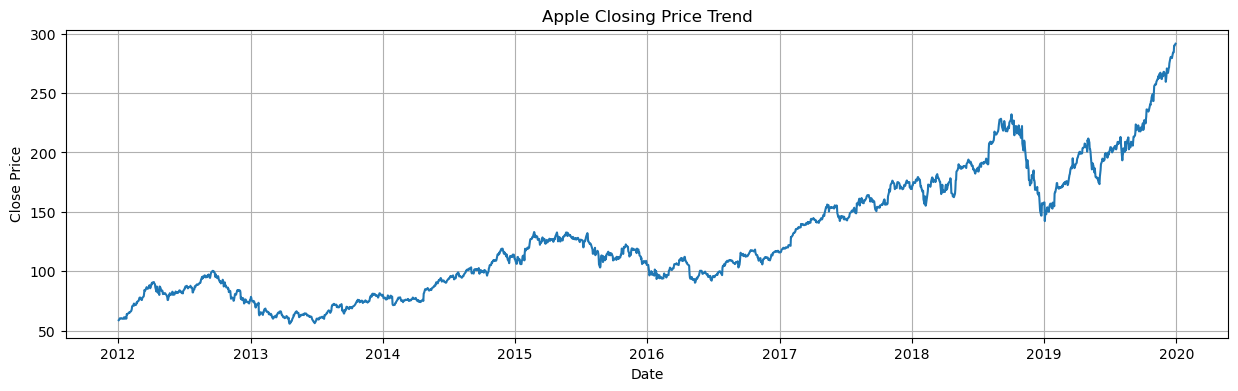

In [14]:
## closing price visualization 
plt.figure(figsize=(15,4))
plt.plot(df['Close'])
plt.title("Apple Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)

plt.show()

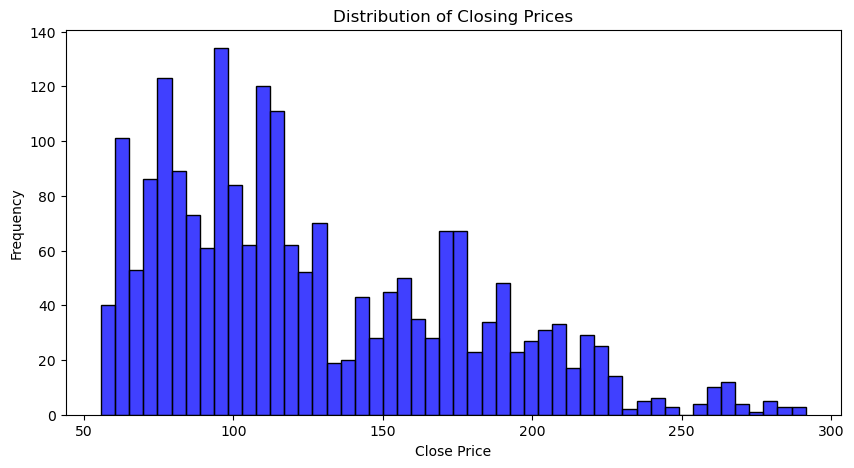

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Close'],
    bins=50,
    color='blue',
    edgecolor='black'
)

plt.title('Distribution of Closing Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.show()

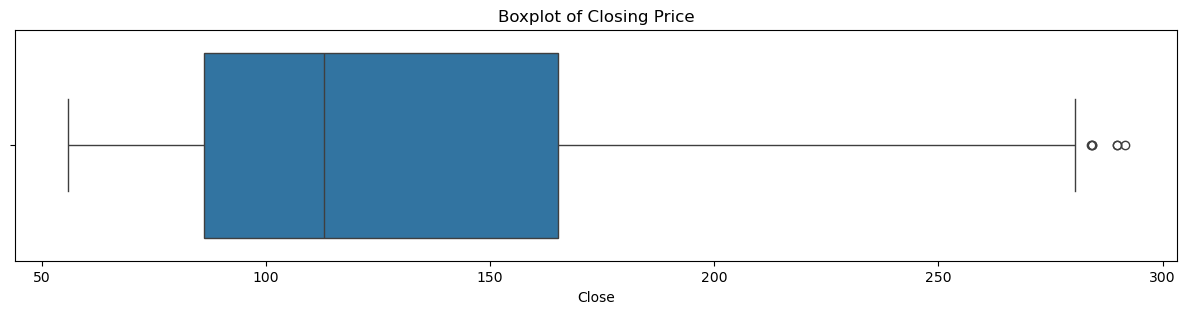

In [16]:
#box plot --> to detect outliers in closing price 
plt.figure(figsize=(15,3))
sns.boxplot(x=df['Close'])
plt.title("Boxplot of Closing Price")
plt.show()

In [17]:
# Using IQR method to count outliers in Close column

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 6


### Rolling mean and standard deviation 

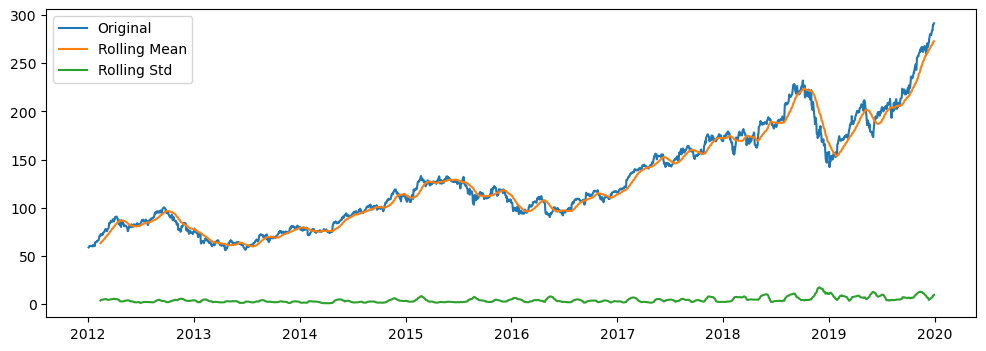

In [18]:
rolling_mean = df['Close'].rolling(window=30).mean()

rolling_std = df['Close'].rolling(window=30).std()

plt.figure(figsize=(12,4))

plt.plot(df['Close'], label='Original')

plt.plot(rolling_mean, label='Rolling Mean')

plt.plot(rolling_std, label='Rolling Std')

plt.legend()

plt.show()

> Rolling mean and standard deviation should be flat ---> if the data is stationary
> 
> But, here in our case std is almost flat with little fluctuations and mean is almost near to original that means our data is not stationary 

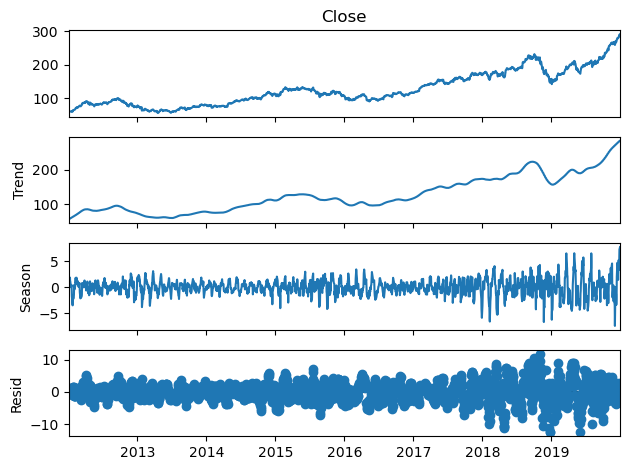

In [19]:
# ETS DECOMPOSITION --> STl
from statsmodels.tsa.seasonal import STL
res = STL(df['Close'], period=30).fit()
res.plot()
plt.show()

## Feature engineering 

In [20]:
# Lag Features
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_3'] = df['Close'].shift(3)
df['lag_7'] = df['Close'].shift(7)

# Moving Averages
df['MA_7'] = df['Close'].rolling(7).mean().shift(1)
df['MA_14'] = df['Close'].rolling(14).mean().shift(1)
df['MA_30'] = df['Close'].rolling(30).mean().shift(1)

# EMA
df['EMA_10'] = (
    df['Close']
    .ewm(span=10, adjust=False)
    .mean()
    .shift(1)
)

# Volatility
df['volatility'] = (
    df['Close']
    .rolling(7)
    .std()
    .shift(1)
)

# Returns
df['Return'] = (
    df['Close']
    .pct_change()
    .shift(1)
)

# Calendar Features
df['Day_of_Week'] = df.index.dayofweek
df['Month'] = df.index.month

# Target
df['target'] = df['Close'].diff()

In [21]:
df = df.dropna()

In [22]:
df.isnull().sum()

Open           0
High           0
Low            0
Close          0
Adj Close      0
Volume         0
lag_1          0
lag_2          0
lag_3          0
lag_7          0
MA_7           0
MA_14          0
MA_30          0
EMA_10         0
volatility     0
Return         0
Day_of_Week    0
Month          0
target         0
dtype: int64

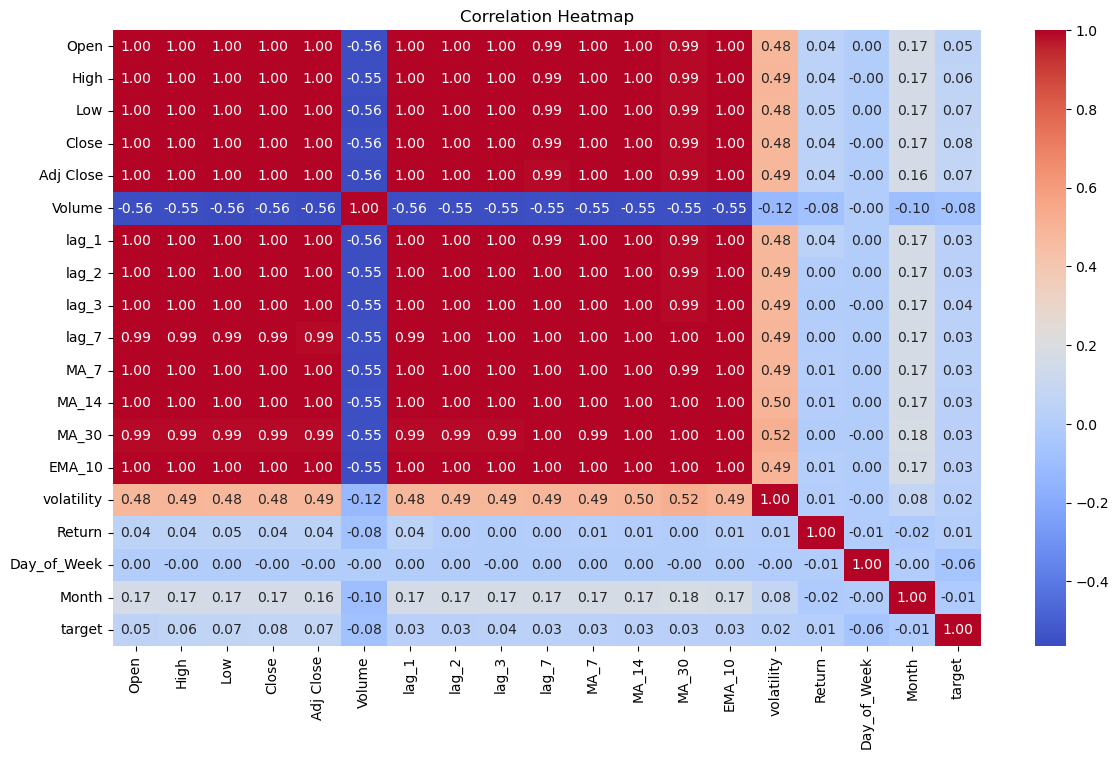

In [23]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [24]:
#df.corr()

In [25]:
## Testing if the data is stationery ---> AUGUMENTED DICKEY FULLER TEST (ADFuller test)
from statsmodels.tsa.stattools import adfuller
def adf_test(data):
    if adfuller(data)[1] > 0.05:
        print('Data is not Stationary')
    else:
        print('Data is stationary')

In [26]:
adf_test(df['Close'])

Data is not Stationary


In [27]:
# Log Transformation
df['Close_log'] = np.log(df['Close']) #Log transformation is used mainly to stabilize variance in time series data.
                                      # Fluctuations become more balanced after log transformation

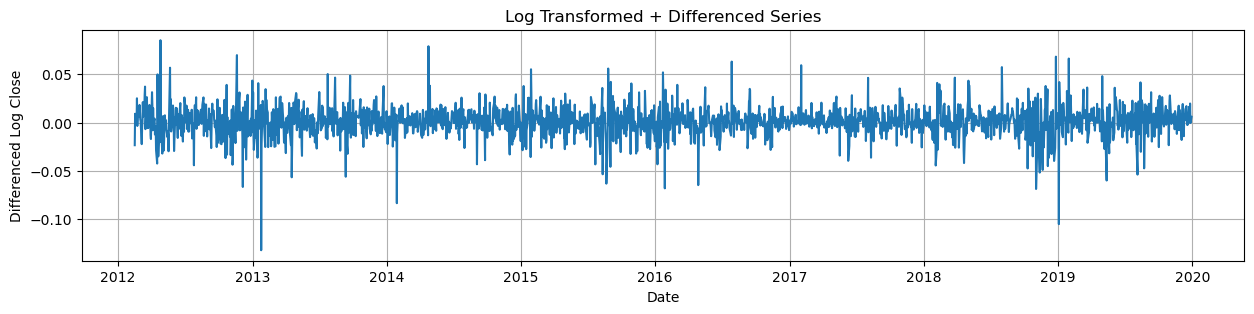

In [28]:
### Differencing 
df['Close_log_diff'] = df['Close_log'].diff()

# Drop null values created after differencing
df['Close_log_diff'].dropna(inplace=True)

# Plot differenced log data
plt.figure(figsize=(15,3))
plt.plot(df['Close_log_diff'])
plt.title("Log Transformed + Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Log Close")
plt.grid(True)
plt.show()

In [29]:
result = adfuller(df['Close_log_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -22.605024806439342
p-value: 0.0


In [30]:
adf_test(df['Close_log_diff'].dropna())

Data is stationary


 #### ACF ---> Auto corelation function (MA) & PACF --> partial auto correlation function 

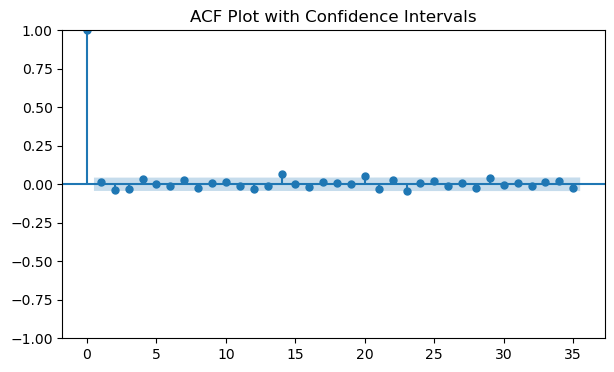

In [31]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF Plot
fig, ax = plt.subplots(figsize=(7,4))

plot_acf(
    df['Close_log_diff'].dropna(),
    lags=35,
    alpha=0.05,
    ax=ax
)

plt.title("ACF Plot with Confidence Intervals")
plt.show()


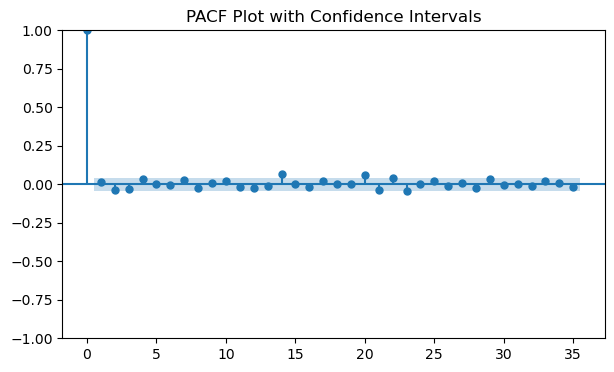

In [36]:
# PACF Plot
fig, ax = plt.subplots(figsize=(7,4))

plot_pacf(
    df['Close_log_diff'].dropna(),
    lags=35,
    alpha=0.05,
    ax=ax
)

plt.title("PACF Plot with Confidence Intervals")
plt.show()

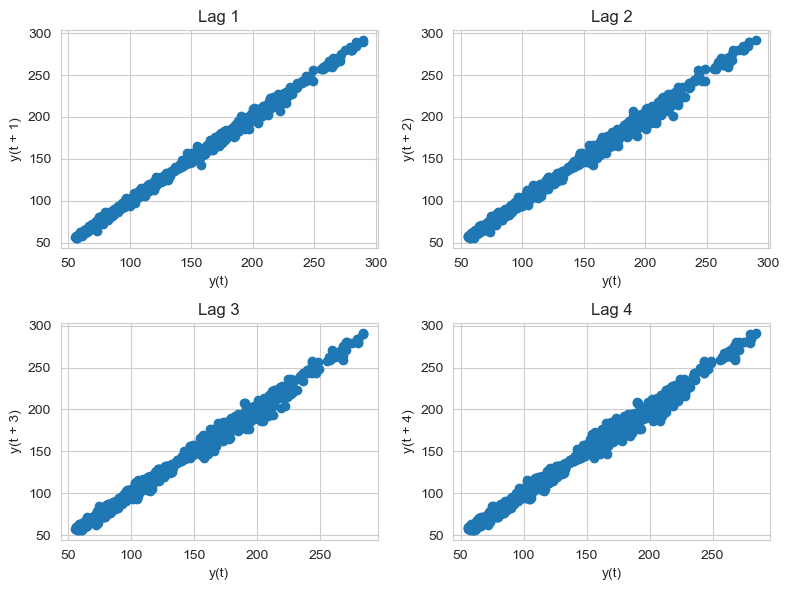

In [77]:
from pandas.plotting import lag_plot
plt.figure(figsize=(8,6))

for i in range(1,5):
    plt.subplot(2,2,i)
    lag_plot(df['Close'], lag=i)
    plt.title(f'Lag {i}')

plt.tight_layout()
plt.show()

> A lag plot is used to check whether the current value has a relationship with its previous values.
If the points form a pattern or lie close to a diagonal line, it indicates autocorrelation in the data.
It helps determine whether lag features can be useful for time series forecasting models.


 ### TRAIN TEST SPLIT (CHRONOLOGICAL)


In [38]:
# Features and Target
X = df.drop(columns=['Close'])
y = df['Close']

# Split index (80% train, 20% test)
split_index = int(len(df) * 0.80)

# Chronological split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (1644, 20)
X_test Shape : (411, 20)
y_train Shape : (1644,)
y_test Shape : (411,)


In [39]:
df.shape

(2055, 21)

In [40]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

### MODEL BUILDING AND EVALUATION 

In [41]:
from pmdarima import auto_arima

auto_arima_model = auto_arima(
    y_train,
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6258.849, Time=1.77 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6266.587, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6266.038, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6265.898, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6267.755, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6268.953, Time=0.85 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=6268.781, Time=0.67 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=6261.019, Time=2.28 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=6261.016, Time=1.62 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6267.532, Time=0.45 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6267.265, Time=0.70 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=6267.903, Time=0.85 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=6262.791, Time=2.39 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=6260.028, Time=0.89 sec

Best model:  ARIMA(2,1,2)(0,0,0)

### BUILD ARIMA MODEL

In [42]:
from statsmodels.tsa.arima.model import ARIMA

# Build Model
arima_model = ARIMA(
    y_train_log,
    order=(2,1,2)
)

# Train Model
arima_result = arima_model.fit()

# Model Summary
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1644
Model:                 ARIMA(2, 1, 2)   Log Likelihood                4520.832
Date:                Sat, 06 Jun 2026   AIC                          -9031.664
Time:                        09:54:00   BIC                          -9004.643
Sample:                    02-14-2012   HQIC                         -9021.644
                         - 06-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6180      1.173     -0.527      0.598      -2.917       1.681
ar.L2         -0.3826      0.629     -0.608      0.543      -1.615       0.850
ma.L1          0.6514      1.176      0.554      0.5

In [43]:
# Training predictions
train_pred_log = arima_result.fittedvalues

# Convert to original scale
train_pred_actual = np.exp(train_pred_log)

In [44]:
# Testing predictions 
# Forecast in log scale
forecast_log = arima_result.forecast(
    steps=len(y_test)
)

# Convert to original scale ONLY ONCE
forecast_actual = np.exp(forecast_log)

print(forecast_actual.head())

2018-06-04    190.361640
2018-06-05    190.284460
2018-06-06    190.285613
2018-06-07    190.314429
2018-06-08    190.296178
Freq: B, Name: predicted_mean, dtype: float64


### ARIMA Evalution Training and testing 

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np


def evaluate_forecast(y_true, y_pred):
    
    # MAE
    mae = mean_absolute_error(y_true, y_pred)
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE
    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100
    
    # Print results
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("MAPE :", mape)
    

In [46]:
print("===== ARIMA TRAIN =====")
evaluate_forecast(
    y_train,
    train_pred_actual
)

print("\n===== ARIMA TEST =====")
evaluate_forecast(
    y_test,
    forecast_actual
)

===== ARIMA TRAIN =====
MAE  : 1.1662166507927598
RMSE : 2.403456229270539
MAPE : 1.1323995870396102

===== ARIMA TEST =====
MAE  : 25.18848885028712
RMSE : 33.6600467382618
MAPE : 11.667557269864044


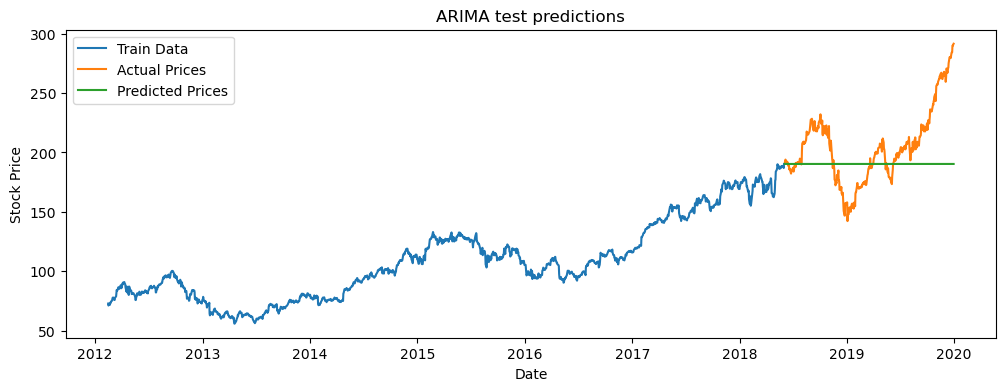

In [47]:
plt.figure(figsize=(12,4))

# Train Data
plt.plot(
    y_train.index,
    y_train,
    label='Train Data')

# Actual Test Data
plt.plot(
    y_test.index,
    y_test,
    label='Actual Prices')

# Predicted Prices
plt.plot(
    y_test.index,
    forecast_actual,
    label='Predicted Prices')

plt.title("ARIMA test predictions")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

 ARIMA captured the overall price level
 but struggled to model rapid nonlinear
 fluctuations in stock prices.

### Retrain ARIMA on full dataset 

In [82]:
y_full = df['Close']

y_full_log = np.log(y_full)

final_arima = ARIMA(
    y_full_log,
    order=(2,1,2)
)

final_arima_result = final_arima.fit()

In [84]:
future_log = final_arima_result.forecast(steps=30)

future_forecast = np.exp(future_log)

print(future_forecast.head())

2019-12-31    291.457215
2020-01-01    291.531015
2020-01-02    291.563334
2020-01-03    291.512214
2020-01-06    291.497028
Freq: B, Name: predicted_mean, dtype: float64


In [85]:
future_dates = pd.date_range(
    start=y_full.index[-1],
    periods=31,
    freq='B'
)[1:]

In [87]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Close': future_forecast.values
})

forecast_df.head()

,Date,Forecast_Close
0,2019-12-31,291.457215
1,2020-01-01,291.531015
2,2020-01-02,291.563334
3,2020-01-03,291.512214
4,2020-01-06,291.497028


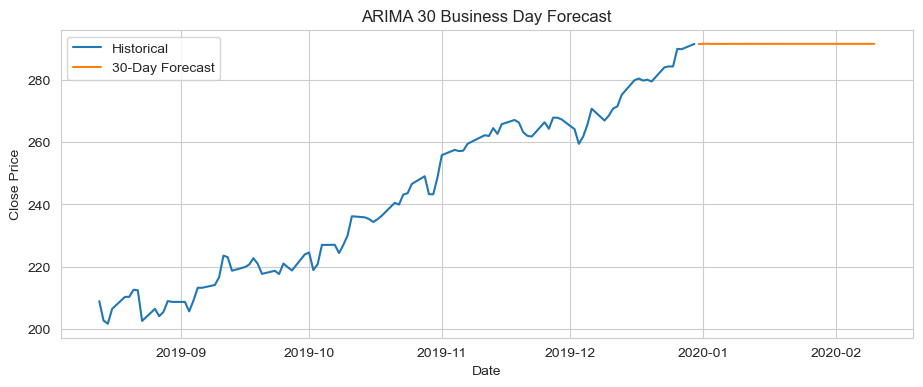

In [90]:
plt.figure(figsize=(11,4))

sns.lineplot(
    x=y_full.index[-100:],
    y=y_full.tail(100),
    label='Historical'
)

sns.lineplot(
    x=future_dates,
    y=future_forecast,
    label='30-Day Forecast'
)

plt.title('ARIMA 30 Business Day Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.show()

### PROPHET

In [48]:
# PREPARE DATA FOR PROPHET

# Create Prophet DataFrame
prophet_df = df.reset_index()[['Date', 'Close']]

# Rename columns
prophet_df.columns = ['ds', 'y']

# Display
prophet_df.head()

,ds,y
0,2012-02-14,72.779999
1,2012-02-15,71.095711
2,2012-02-16,71.744286
3,2012-02-17,71.731430
4,2012-02-20,71.731430


In [49]:
# TRAIN TEST SPLIT

split_index = int(len(prophet_df) * 0.80)

train_prophet = prophet_df.iloc[:split_index]
test_prophet = prophet_df.iloc[split_index:]

print(train_prophet.shape)
print(test_prophet.shape)

(1644, 2)
(411, 2)


In [124]:
# BUILD PROPHET MODEL

from prophet import Prophet

# Initialize model
prophet_model = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.5,
    n_changepoints=100
)

# Train model
prophet_model.fit(train_prophet)

10:39:06 - cmdstanpy - INFO - Chain [1] start processing
10:39:09 - cmdstanpy - INFO - Chain [1] done processing


In [125]:
# FORECAST TEST DATA

# Create future dataframe
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq='B'
)

# Forecast
forecast_prophet = prophet_model.predict(future)

# Display forecast
forecast_prophet[['ds', 'yhat']].tail()

,ds,yhat
2050,2019-12-24,236.596748
2051,2019-12-25,236.690608
2052,2019-12-26,236.784468
2053,2019-12-27,236.878329
2054,2019-12-30,237.159910


In [126]:
# Training predictions only
train_predictions_prophet = forecast_prophet.iloc[
    :len(train_prophet)
]

# Predicted train values
y_train_pred_prophet = train_predictions_prophet['yhat']

# Actual train values
y_train_actual_prophet = train_prophet['y']

In [127]:
# TEST PREDICTIONS

# Take only test predictions
predictions_prophet = forecast_prophet.iloc[-len(test_prophet):]

# Predicted values
y_pred_prophet = predictions_prophet['yhat']

# Actual values
y_actual_prophet = test_prophet['y']

In [128]:
# TRAIN VS TEST COMPARISON
print("===== PROPHET TRAIN =====")

evaluate_forecast(
    y_train_actual_prophet,
    y_train_pred_prophet
)

print("\n===== PROPHET TEST =====")

evaluate_forecast(
    y_actual_prophet,
    y_pred_prophet
)

===== PROPHET TRAIN =====
MAE  : 2.4845826998300544
RMSE : 3.4148099612274905
MAPE : 2.2483447463067745

===== PROPHET TEST =====
MAE  : 22.926830320792988
RMSE : 26.746923787726146
MAPE : 11.73254709657546


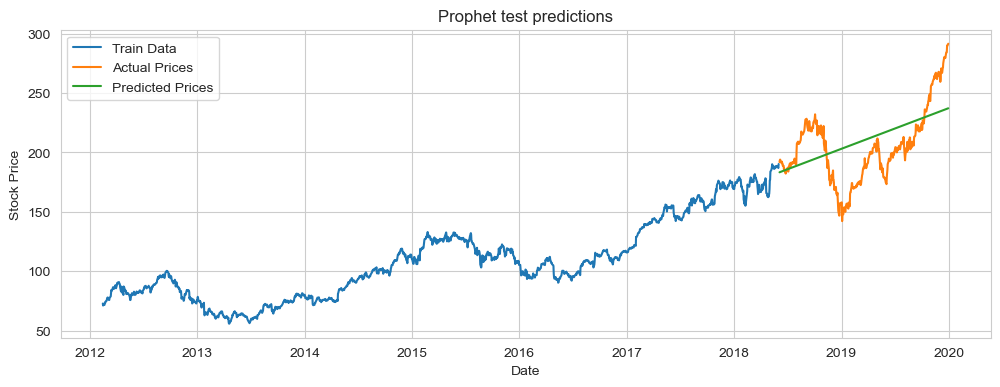

In [129]:
# PROPHET FORECAST PLOT
plt.figure(figsize=(12,4))

# Train data
plt.plot(
    train_prophet['ds'],
    train_prophet['y'],
    label='Train Data')

# Actual test data
plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Actual Prices')

# Predicted prices
plt.plot(
    test_prophet['ds'],
    y_pred_prophet,
    label='Predicted Prices')
plt.title("Prophet test predictions")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

#### Retrain prophet with fulll dataset

In [132]:
full_prophet = prophet_df.copy()

# Initialize model
final_prophet = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.5,
    n_changepoints=100
)

# Train on full data
final_prophet.fit(full_prophet)

10:39:26 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing


In [133]:
future_30 = final_prophet.make_future_dataframe(
    periods=30,
    freq='B'
)

forecast_30 = final_prophet.predict(future_30)

In [134]:
future_forecast = forecast_30[['ds', 'yhat']].tail(30)

future_forecast.columns = [
    'Date',
    'Forecast_Close'
]

future_forecast.head()

,Date,Forecast_Close
2055,2019-12-31,231.162533
2056,2020-01-01,231.253829
2057,2020-01-02,231.345126
2058,2020-01-03,231.436422
2059,2020-01-06,231.710311


In [135]:
#print(future_forecast)

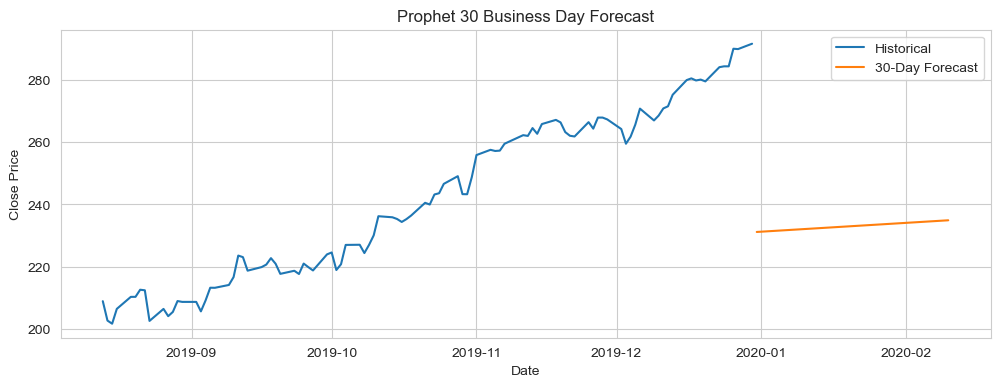

In [136]:
plt.figure(figsize=(12,4))

sns.lineplot(
    x=prophet_df['ds'].tail(100),
    y=prophet_df['y'].tail(100),
    label='Historical'
)

sns.lineplot(
    x=future_forecast['Date'],
    y=future_forecast['Forecast_Close'],
    label='30-Day Forecast'
)

plt.title('Prophet 30 Business Day Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.show()

## XGBoost

In [137]:
features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'MA_7',
    'MA_14',
    'MA_30',
    'EMA_10',
    'volatility',
    'Return',
    'Month',
    'Day_of_Week'
]

In [138]:
# prepare Dataset
df_xgb = df.dropna().copy()
X = df_xgb[features]
y = df_xgb['target']

In [139]:
#df_xgb.head()

In [140]:
# TRAIN-TEST SPLIT IN CHRONOLOGICAL ORDER 
split_index = int(len(df_xgb) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [141]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [142]:
#the models predicts next days price differnce rather than actual closing price directly 
train_pred_diff = xgb_model.predict(X_train)
test_pred_diff = xgb_model.predict(X_test)

In [143]:
#Convert Difference → Close Price
train_pred_close = (
    X_train['lag_1'] +
    train_pred_diff
)

test_pred_close = (
    X_test['lag_1'] +
    test_pred_diff
)

In [144]:
#Actual Close Prices
actual_train_close = df_xgb['Close'].iloc[:split_index]

actual_test_close = df_xgb['Close'].iloc[split_index:]

In [145]:
print(len(actual_train_close))
print(len(train_pred_close))

print(len(actual_test_close))
print(len(test_pred_close)) ## must be same length

1643
1643
411
411


In [146]:
print("===== XGBOOST TRAIN =====")

evaluate_forecast(
     actual_train_close,
    train_pred_close)
print("===== XGBOOST TEST =====")

evaluate_forecast(
    actual_test_close,
    test_pred_close)

===== XGBOOST TRAIN =====
MAE  : 0.4355644920150203
RMSE : 0.5776197084342326
MAPE : 0.43269716422316706
===== XGBOOST TEST =====
MAE  : 2.667406171345267
RMSE : 3.587995508895324
MAPE : 1.3256629174055627


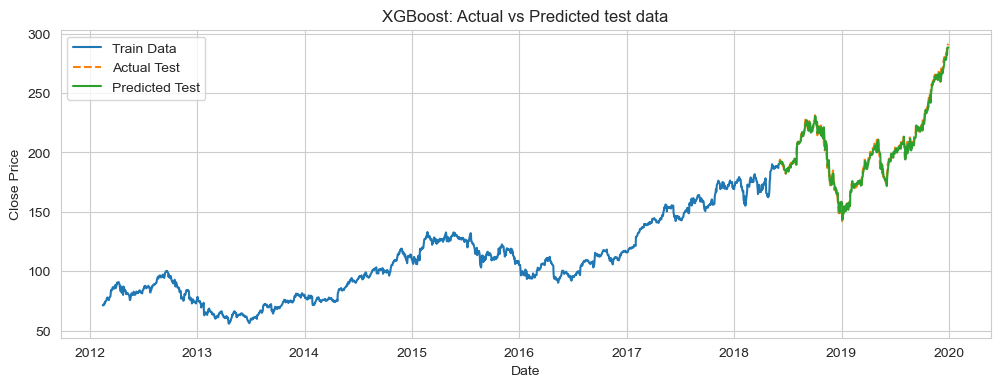

In [162]:
plt.figure(figsize=(12,4))

sns.lineplot(
    x=actual_train_close.index,
    y=actual_train_close,
    label='Train Data'
)

plt.plot(
    actual_test_close.index,
    actual_test_close,
    '--',
    label='Actual Test'
)

plt.plot(
    actual_test_close.index,
    test_pred_close,
    label='Predicted Test'
)

plt.title("XGBoost: Actual vs Predicted test data")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()

plt.show()

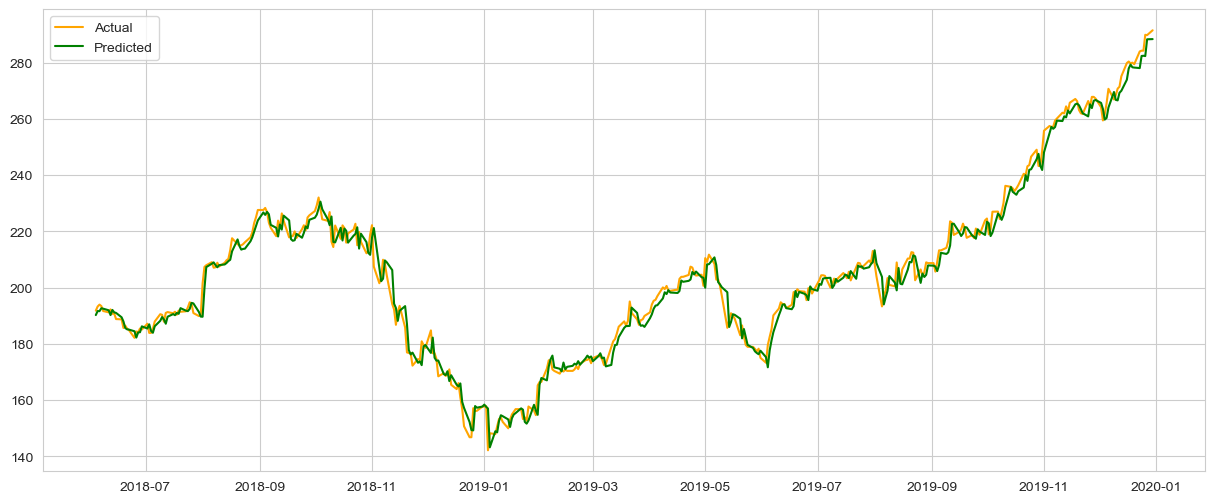

In [163]:
## To see testing plot actual vs predicted clearly
plt.figure(figsize=(15,6))

plt.plot(
    actual_test_close.index,
    actual_test_close,
    label='Actual',
    color = 'orange'
)

plt.plot(
    actual_test_close.index,
    test_pred_close,
    label='Predicted',
    color = 'green'
)

plt.legend()
plt.show()

In [148]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

        Feature  Importance
7        EMA_10    0.100241
6         MA_30    0.095031
3         lag_7    0.090559
5         MA_14    0.089977
4          MA_7    0.087984
8    volatility    0.085645
2         lag_3    0.084997
9        Return    0.081984
10        Month    0.075717
1         lag_2    0.074244
11  Day_of_Week    0.068325
0         lag_1    0.065296


### MODEL COMPARISION

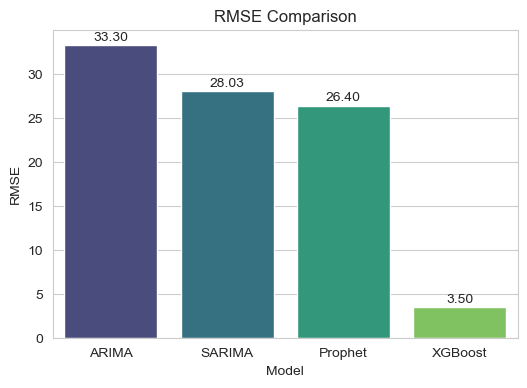

In [149]:
results = pd.DataFrame({
    'Model':['ARIMA','SARIMA','Prophet','XGBoost'],
    'RMSE':[33.30,28.03,26.40,3.50]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=results,
    x='Model',
    y='RMSE',
    hue='Model',
    palette='viridis',
    legend=False
)

for i, v in enumerate(results['RMSE']):
    ax.text(i, v+0.5, f'{v:.2f}', ha='center')

plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.show()

#### TRAIN VS TEST RMSE 

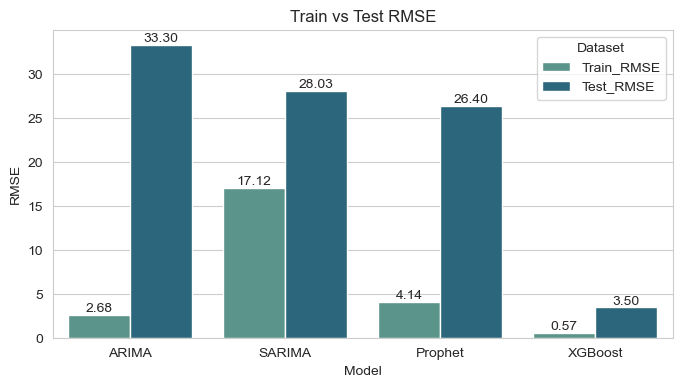

In [150]:
comparison = pd.DataFrame({
    'Model':['ARIMA','SARIMA','Prophet','XGBoost'],
    'Train_RMSE':[2.68,17.12,4.14,0.57],
    'Test_RMSE':[33.30,28.03,26.40,3.50]
})

comparison_melt = comparison.melt(
    id_vars='Model',
    var_name='Dataset',
    value_name='RMSE'
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=comparison_melt,
    x='Model',
    y='RMSE',
    hue='Dataset',
    palette='crest'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Train vs Test RMSE')
plt.ylabel('RMSE')
plt.show()

##### XGBoost emerged as the best-performing model with a Test RMSE of 3.50 and MAPE of 1.26%, substantially outperforming ARIMA, SARIMA, and Prophet.
#### Hence, XGBoost was selected for final stock price forecasting.

### Retrain on Full Dataset --> XGBoost 

In [151]:
xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_final.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [152]:
# create a forecast Loop
history = df_xgb.copy()
future_predictions = []

### Forecast for next 30 days

In [153]:
for i in range(30):

    latest = history.iloc[-1]

    future_row = pd.DataFrame({
        'lag_1':[latest['Close']],
        'lag_2':[history['Close'].iloc[-2]],
        'lag_3':[history['Close'].iloc[-3]],
        'lag_7':[history['Close'].iloc[-7]],

        'MA_7':[history['Close'].tail(7).mean()],
        'MA_14':[history['Close'].tail(14).mean()],
        'MA_30':[history['Close'].tail(30).mean()],

        'EMA_10':[history['Close'].ewm(span=10).mean().iloc[-1]],

        'volatility':[history['Close'].tail(7).std()],

        'Return':[history['Close'].pct_change().iloc[-1]],

        'Month':[history.index[-1].month],

        'Day_of_Week':[(history.index[-1].dayofweek + 1) % 5]
    })

    pred_diff = xgb_final.predict(future_row)[0]

    pred_close = latest['Close'] + pred_diff

    future_predictions.append(pred_close)

    next_date = history.index[-1] + pd.offsets.BDay(1)

    new_row = latest.copy()

    new_row['Close'] = pred_close

    history.loc[next_date] = new_row

In [154]:
#Future Dates 
future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.BDay(1),
    periods=30,
    freq='B'
)

In [155]:
# forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Close': future_predictions
})

forecast_df.head()

,Date,Forecast_Close
0,2019-12-31,292.373528
1,2020-01-01,294.008999
2,2020-01-02,294.553679
3,2020-01-03,296.212109
4,2020-01-06,296.906643


In [156]:
forecast_df.tail()

,Date,Forecast_Close
25,2020-02-04,307.898807
26,2020-02-05,306.942446
27,2020-02-06,307.622504
28,2020-02-07,308.975384
29,2020-02-10,309.802193


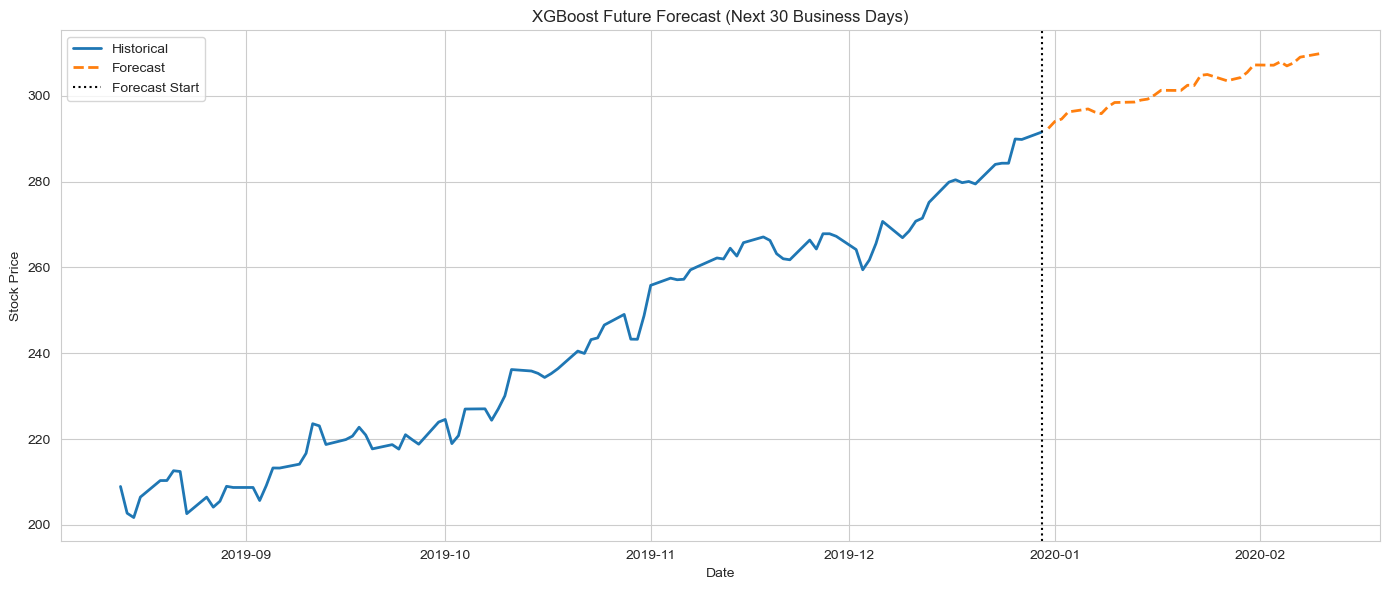

In [157]:
# Future Forcast --> XGBOOST for 30 DAYS
sns.set_style("whitegrid")

plt.figure(figsize=(14,6))

# Historical
sns.lineplot(
    x=df.index[-100:],
    y=df['Close'].tail(100),
    linewidth=2,
    label='Historical'
)

# Forecast
sns.lineplot(
    x=future_dates,
    y=future_predictions,
    linewidth=2,
    linestyle='--',
    label='Forecast'
)

# Split line
plt.axvline(
    x=df.index[-1],
    linestyle=':',
    color='black',
    label='Forecast Start'
)

plt.title('XGBoost Future Forecast (Next 30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()

plt.tight_layout()
plt.show()

### FINAL CONCLUSION

### Among all the models tested, XGBoost achieved the best forecasting performance with the lowest prediction error. Therefore, XGBoost was selected as the final model and used to forecast the next 30 business days of Apple stock prices. The forecast indicates a positive upward trend in the stock price over the forecast period.

### Future forecast Deployment using  streamlit

In [166]:
forecast_df.to_csv(
    "future_forecast.csv",
    index=False
)

In [167]:
historical_data = df[['Close']].reset_index()

historical_data.to_csv(
    "historical_data.csv",
    index=False
)